# **Analisis Exploratorio de Metrobus**

1. Introducción

2. Objetivos

3. Importación de librerías

4. Configuración de Pandas

5. Carga de datos

6. Resumen general
    - dimensiones
    - memoria
    - nulos
    - duplicados

7. Análisis individual

    * 7.1 Viajes
    * 7.2 Mantenimiento
    * 7.3 Incidencias
    * 7.4 Conductores
    * 7.5 Cocheras
    * 7.6 Líneas
    * 7.7 Paradas
    * 7.8 Tarifas
    * 7.9 Vehículos

8. Conclusiones

## **1. Introducción**

## **2. Objetivos**

## **3. Importación de librerías**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **4. Configuración de Pandas**

In [2]:
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar todo el texto en las celdas sin truncar
pd.set_option('display.max_colwidth', None)

## **5. Carga de datos**

In [3]:
# Cargamos los archivos CSV en los DataFrames

# Tablas de hechos
df_viajes = pd.read_csv("../data/raw/fact_viajes.csv").set_index('viaje_id')
df_incidencias = pd.read_csv("../data/raw/fact_incidencias.csv").set_index('incidencia_id')
df_mantenimientos = pd.read_csv("../data/raw/fact_mantenimiento.csv").set_index('mantenimiento_id')

# Tablas de dimensión
df_lineas = pd.read_csv("../data/raw/dim_linea.csv").set_index('linea_id')
df_vehiculos = pd.read_csv("../data/raw/dim_vehiculo.csv").set_index('vehiculo_id')
df_conductores = pd.read_csv("../data/raw/dim_conductor.csv").set_index('conductor_id')
df_paradas = pd.read_csv("../data/raw/dim_parada.csv").set_index('parada_id')
df_tarifas = pd.read_csv("../data/raw/dim_tarifa.csv").set_index('tarifa_id')
df_cocheras = pd.read_csv("../data/raw/dim_depot.csv").set_index('depot_id')

## **6. Resumen general**

En este apartado analizamos la estructura de cada tabla para identificar:

* Total de columnas
* Total de filas
* Total de nulos
* Porcentaje de nulos
* Total de duplicados
* Memoria utilizada

In [4]:
dataframes = {
    "viajes": df_viajes,
    "incidencias": df_incidencias,
    "mantenimiento": df_mantenimientos,
    "lineas": df_lineas,
    "vehiculos": df_vehiculos,
    "conductores": df_conductores,
    "paradas": df_paradas,
    "tarifas": df_tarifas,
    "cocheras": df_cocheras
}

In [5]:
# Obtenemos un nuevo DataFrame con los metadatos de todos los datasets
metadatos = {
    'DataFrame': [],
    'Columnas': [],
    'Filas': [],
    'Nulos': [],
    '% Nulos': [],
    'Duplicados': [],
    'Memoria MB': []
}

for name, dataframe in dataframes.items():
    nulos = dataframe.isnull().sum().sum()
    filas = dataframe.shape[0]

    metadatos["DataFrame"].append(name)
    metadatos["Columnas"].append(dataframe.shape[1])
    metadatos["Filas"].append(filas)
    metadatos["Nulos"].append(nulos)
    metadatos["% Nulos"].append(round(((nulos/filas) * 100), 2))
    metadatos["Duplicados"].append(dataframe.duplicated().sum())
    metadatos["Memoria MB"].append(round(dataframe.memory_usage(deep=True).sum() / (1024 **2), 3))

df_estructura_general = pd.DataFrame(metadatos).set_index('DataFrame')
df_estructura_general

,Columnas,Filas,Nulos,% Nulos,Duplicados,Memoria MB
DataFrame,,,,,,
viajes,23,50000,1105,2.21,0,22.212
incidencias,15,4000,0,0.00,0,1.378
mantenimiento,14,876,15,1.71,0,0.317
lineas,6,10,0,0.00,0,0.002
vehiculos,11,45,1,2.22,0,0.010
conductores,9,30,1,3.33,0,0.008
paradas,9,120,2,1.67,0,0.029
tarifas,5,9,0,0.00,0,0.001
cocheras,5,3,0,0.00,0,0.000


## **7. Análisis individual**

En este apartado se realiza un análisis individual de cada tabla del dataset con el objetivo de comprender su estructura, calidad y distribución de los datos.

Para cada columna se analizan los siguientes aspectos:

* Tipo de dato de cada atributo.
* Número total de valores nulos.
* Porcentaje de valores nulos respecto al total de registros.
* Cantidad de valores únicos para conocer la cardinalidad de los datos.
* Moda de cada columna para identificar los valores más repetidos.
* Número total de filas y columnas de cada tabla.
* Valor más frecuente (`top`) y su frecuencia (`freq`) de aparición.
* Medidas estadísticas descriptivas para variables numéricas:
  * Media.
  * Desviación estándar.
  * Moda
  * Valor mínimo.
  * Valor máximo.

Este análisis permite detectar problemas de calidad de datos, identificar posibles valores atípicos y comprender la distribución de las variables antes de realizar las transformaciones y análisis posteriores.

In [6]:
def es_numero(columna):
    return columna.dtype in [int, float, bool]

def es_object(columna):
    return columna.dtype in [object, str]

In [7]:
def pasar_int_a_str(lista):
    return [str(n) for n in lista]

def obtener_valores(columna):
    return ", ".join([str(x) for x in columna.dropna().unique()[:3]])

In [8]:
def calcular_nulos(columna):
    return columna.isnull().sum()

def calcular_porcentaje_nulos(columna):
    return round((calcular_nulos(columna)/ columna.size) * 100, 2)

def calcular_valores_unicos(columna):
    return len(columna.unique())

def calcular_top(columna):
    return columna.value_counts().index[0] if es_object(columna) else np.nan

def calcular_frecuencia(columna):
    return columna.value_counts().iloc[0] if es_object(columna) else np.nan

def calcular_media(columna):
    return round( np.mean(columna), 2) if es_numero(columna) else np.nan

def calcular_std(columna):
    return round(np.std(columna), 2) if es_numero(columna) else np.nan

def calcular_moda(columna):
    lista_con_str = pasar_int_a_str(list(columna.mode())[:6])
    resultado = " - ".join(lista_con_str) + " - ..." if len(lista_con_str) > 5 else ("".join(lista_con_str) if len(lista_con_str) == 1 else " - ".join(lista_con_str))
    
    return resultado if es_numero(columna) else np.nan

def calcular_min(columna):
    return columna.min() if es_numero(columna) else np.nan

def calcular_max(columna):
    return columna.max() if es_numero(columna) else np.nan

In [9]:
def crear_tabla_metadatos(df):

    return pd.DataFrame(
                data= {
                        'Columna': df.columns,
                        'Tipo_Dato': df.dtypes,
                        'Valores_Nulos': df.apply(calcular_nulos, axis=0), 
                        'Porcentaje_Nulos': df.apply(calcular_porcentaje_nulos, axis=0),
                        'Valores_Unicos': df.apply(calcular_valores_unicos, axis=0),
                        'Filas': df.shape[0],
                        'Columnas': df.shape[1],
                        'Media': df.apply(calcular_media, axis=0),
                        'Desviacion': df.apply(calcular_std, axis=0),
                        'Moda': df.apply(calcular_moda, axis=0),
                        'Minimo': df.apply(calcular_min, axis=0),
                        'Maximo': df.apply(calcular_max, axis=0),
                        'Top': df.apply(calcular_top, axis=0),
                        'Frecuencia_Moda': df.apply(calcular_frecuencia, axis=0),
                        'Ejemplo de Valores (Max.3)': df.apply(obtener_valores, axis=0)

                }).set_index('Columna').sort_values(by='Tipo_Dato')  # Ordena las columnas por tipo de dato para agrupar los valores estadísticos válidos y evitar la alternancia entre valores y NaN.

## **7.1 Viajes**

### **7.1.1 Analisis Inicial**

In [10]:
df_viajes.head(3)

,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
viaje_id,,,,,,,,,,,,,,,,,,,,,,,
1,4,2,2,17,116,2023-08-14,2023,8,Monday,False,Tarde punta,17:50,18:09,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
2,4,3,3,5,48,2024-05-20,2024,5,Monday,False,Manana punta,07:10,07:23,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,False,Valle manana,12:30,12:30,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3


In [11]:
df_viajes_metadatos = crear_tabla_metadatos(df_viajes)
df_viajes_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
viaje_completado,bool,0,0.00,2,50000,23,0.98,0.14,True,False,True,NaN,NaN,"True, False"
es_festivo,bool,0,0.00,2,50000,23,0.28,0.45,False,False,True,NaN,NaN,"False, True"
linea_id,int64,0,0.00,10,50000,23,5.50,2.87,7,1,10,NaN,NaN,"4, 5, 2"
duracion_real_min,int64,0,0.00,105,50000,23,62.60,23.85,39,25,129,NaN,NaN,"73, 67, 35"
retraso_salida_min,int64,0,0.00,55,50000,23,3.89,6.76,0,-99,50,NaN,NaN,"19, 13, 0"
mes,int64,0,0.00,12,50000,23,6.52,3.45,8,1,12,NaN,NaN,"8, 5, 3"
tarifa_predominante_id,int64,0,0.00,9,50000,23,3.61,2.16,3,1,9,NaN,NaN,"4, 2, 3"
parada_destino_id,int64,0,0.00,80,50000,23,80.45,23.13,104,41,120,NaN,NaN,"116, 48, 110"
parada_origen_id,int64,0,0.00,40,50000,23,20.55,11.56,28,1,40,NaN,NaN,"17, 5, 33"


In [12]:
df_viajes.retraso_salida_min.min()

np.int64(-99)

In [13]:
df_viajes.dia_semana.unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday',
       'Saturday', 'SATURDAY', 'SUNDAY', 'FRIDAY', 'TUESDAY', 'WEDNESDAY',
       'MONDAY', 'THURSDAY'], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_viajes` permite concluir que, en términos generales, la tabla presenta una buena calidad de los datos, ya que la mayoría de las columnas no contienen valores nulos y el rango de los valores es coherente. No obstante, se han identificado varios aspectos que requieren una revisión más detallada en las siguientes fases del EDA: 

* La columna **dia_semana** presenta 14 valores únicos, un rango superior a lo esperado para una variable que representa los días de la semana. 

* La columna **consumo** contiene 1.065 valores nulos (2,13 %), siendo la variable con mayor cantidad de datos ausentes. Asimismo, la columna **pasajeros_subidos** presenta un total de 40 valores nulos (0,08 %).

* También se ha detectado que la variable **retraso_salida_min** tiene un valor mínimo de -99 minutos, un dato poco plausible desde el punto de vista operativo.

Por último, las columnas **fecha, hora_salida_real, hora_llegada_real y hora_salida_prog** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

### **7.1.2 Outliers**

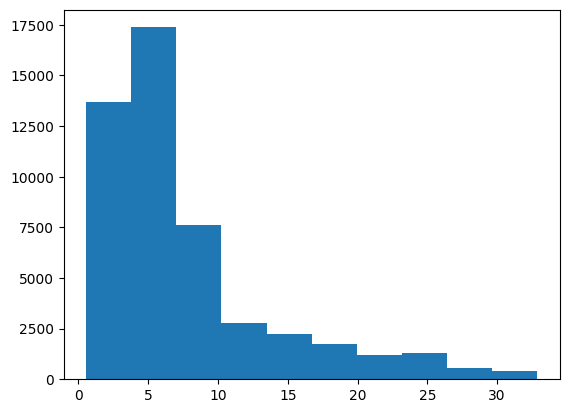

In [21]:
plt.hist(df_viajes.consumo)
plt.show()

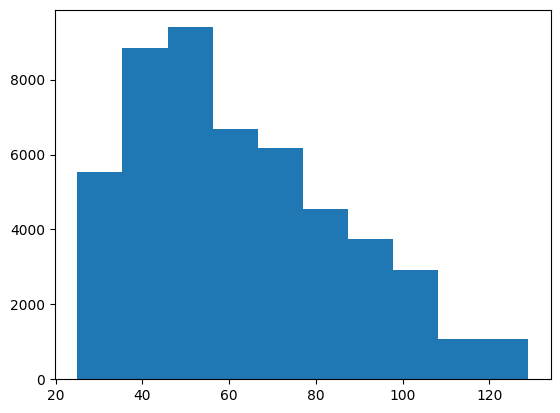

In [22]:
plt.hist(df_viajes.duracion_real_min)
plt.show()

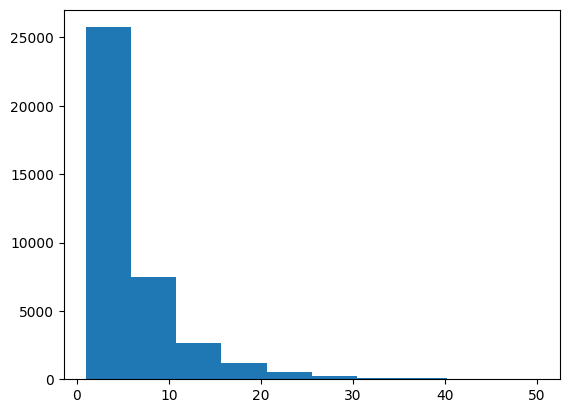

In [ ]:
# Eliminamos el valor -99
df = df_viajes[df_viajes.retraso_salida_min > 0]

plt.hist(df.retraso_salida_min)
plt.show()

## **7.2 Mantenimiento**

In [ ]:
df_mantenimientos.head(3)

,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
mantenimiento_id,,,,,,,,,,,,,,
1,1,1,2024-07-24,2024-07-25,2024,7,Cambio aceite,Preventivo,False,1,278454,218.70,TallerBus Norte,0
2,1,1,2023-02-08,2023-02-09,2023,2,Cambio neumaticos,Preventivo,False,1,240059,1068.93,TallerBus Norte,0
3,1,1,2024-10-28,2024-10-29,2024,10,Cambio neumaticos,Preventivo,False,1,493071,722.19,Taller Oficial Mercedes,0


In [ ]:
df_mantenimientos_metadatos = crear_tabla_metadatos(df_mantenimientos)
df_mantenimientos_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
es_correctivo,bool,0,0.00,2,876,14,0.38,0.49,False,False,True,NaN,NaN,"False, True"
vehiculo_id,int64,0,0.00,45,876,14,22.71,12.83,18 - 19 - 26,1,45,NaN,NaN,"1, 2, 3"
depot_id,int64,0,0.00,3,876,14,1.85,0.78,1,1,3,NaN,NaN,"1, 2, 3"
anno,int64,0,0.00,4,876,14,2023.25,0.88,2024,2022,2025,NaN,NaN,"2024, 2023, 2022"
mes,int64,0,0.00,12,876,14,6.28,3.67,1,1,12,NaN,NaN,"7, 2, 10"
dias_fuera_servicio,int64,0,0.00,11,876,14,1.90,1.96,1,0,10,NaN,NaN,"1, 2, 0"
km_en_revision,int64,0,0.00,876,876,14,277372.78,155954.86,10222 - 10242 - 10393 - 11101 - 11841 - 12536 - ...,10222,549625,NaN,NaN,"278454, 240059, 493071"
garantia_meses,int64,0,0.00,4,876,14,2.08,3.87,0,0,12,NaN,NaN,"0, 6, 12"
coste_eur,float64,0,0.00,872,876,14,742.52,924.28,144.35 - 154.34 - 173.35 - 218.7,-4083.03,4987.72,NaN,NaN,"218.7, 1068.93, 722.19"


In [ ]:
df_mantenimientos.coste_eur[df_mantenimientos.coste_eur < 0.00].unique()

array([ -866.9 , -1077.87,  -193.6 ,  -211.69,  -222.12, -1047.04,
        -810.99,  -361.3 ,  -786.21, -2942.78,  -233.91,  -349.48,
        -223.52, -1058.18,  -506.81, -4083.03, -1051.12,  -297.65,
        -353.61, -1065.44,  -405.2 ,  -347.52,  -402.29,  -806.4 ,
        -150.88])

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame df_mantenimiento permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* Se ha detectado una discrepancia temporal en los datos, ya que la columna **anno** contiene registros correspondientes al año 2025, mientras que la información proporcionada indica que los archivos CSV representan datos históricos de MetroBus comprendidos entre los años 2022 y 2024.

*  La columna **coste_euros** presenta valores negativos, un comportamiento que no resulta coherente desde el punto de vista operativo.

* La columna **categoria** presenta 15 valores nulos, lo que representa aproximadamente un 1,71 % del total de registros.

Por ultimo, Las columnas relacionadas con **fechas** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

## **7.3 Incidencias**

In [ ]:
df_incidencias.head(3)

,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
incidencia_id,,,,,,,,,,,,,,,
1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.00
2,9428,21,21,6,2023-02-16,2023,2,20:42,Fallo electrico,Vehiculo,Alta,True,62,False,575.51
3,200,33,5,8,2022-01-20,2022,1,06:21,Accidente leve,Seguridad,Alta,True,29,True,3318.00


In [ ]:
df_incidencias_metadatos = crear_tabla_metadatos(df_incidencias)
df_incidencias_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
requiere_retirada,bool,0,0.0,2,4000,15,0.50,0.50,True,False,True,NaN,NaN,"True, False"
vehiculo_sustituto,bool,0,0.0,2,4000,15,0.36,0.48,False,False,True,NaN,NaN,"False, True"
viaje_id,int64,0,0.0,4000,4000,15,24813.57,14309.33,5 - 63 - 104 - 145 - 148 - 168 - ...,5,49989,NaN,NaN,"33554, 9428, 200"
vehiculo_id,int64,0,0.0,42,4000,15,21.34,12.14,9,1,42,NaN,NaN,"39, 21, 33"
conductor_id,int64,0,0.0,28,4000,15,14.62,8.11,22,1,28,NaN,NaN,"11, 21, 5"
linea_id,int64,0,0.0,10,4000,15,5.56,2.85,7,1,10,NaN,NaN,"4, 6, 8"
anno,int64,0,0.0,3,4000,15,2023.03,0.81,2024,2022,2024,NaN,NaN,"2022, 2023, 2024"
mes,int64,0,0.0,12,4000,15,6.55,3.48,8,1,12,NaN,NaN,"6, 2, 1"
duracion_resolucion_min,int64,0,0.0,183,4000,15,28.61,34.06,5,5,333,NaN,NaN,"60, 62, 29"


In [ ]:
df_incidencias[df_incidencias.coste_estimado_eur == 0].head(3)

,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
incidencia_id,,,,,,,,,,,,,,,
1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.0
8,49499,24,24,5,2023-03-03,2023,3,22:20,Obras calzada,Externo,Media,False,5,False,0.0
9,4145,30,2,5,2024-05-02,2024,5,20:30,Huelga parcial,Operacional,Alta,True,85,True,0.0


## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_incidencias` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **coste_estimado_eur** presenta valores iguales a 0.00, un comportamiento que apriori no resulta coherente desde el punto de vista operativo.

* Las columnas relacionadas con **fechas** y **horas** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

## **7.4 Conductores**

In [ ]:
df_conductores.head(3)

,nombre,anno_incorporacion,antiguedad_anos,turno_habitual,depot_id,formacion,licencia_tipo,activo,ausencias_2024
conductor_id,,,,,,,,,
1,Carlos Garcia,2009,15.0,Partido,3,Basica,D,True,14
2,Maria Lopez,2013,11.0,Noche (22-06h),1,Basica,D,True,9
3,Juan Martinez,2008,16.0,Manana (06-14h),2,Completa,D+E,True,6


In [ ]:
df_conductores_metadatos = crear_tabla_metadatos(df_conductores)
df_conductores_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
activo,bool,0,0.00,2,30,9,0.93,0.25,True,False,True,NaN,NaN,"True, False"
anno_incorporacion,int64,0,0.00,15,30,9,2013.50,5.44,2008 - 2019,2005,2023,NaN,NaN,"2009, 2013, 2008"
depot_id,int64,0,0.00,3,30,9,2.17,0.82,3,1,3,NaN,NaN,"3, 1, 2"
ausencias_2024,int64,0,0.00,13,30,9,8.63,4.96,15,0,15,NaN,NaN,"14, 9, 6"
antiguedad_anos,float64,1,3.33,15,30,9,10.55,5.52,5.0 - 16.0,1.0,19.0,NaN,NaN,"15.0, 11.0, 16.0"
nombre,object,0,0.00,30,30,9,NaN,NaN,NaN,NaN,NaN,Carlos Garcia,1.0,"Carlos Garcia, Maria Lopez, Juan Martinez"
turno_habitual,object,0,0.00,5,30,9,NaN,NaN,NaN,NaN,NaN,Noche (22-06h),8.0,"Partido, Noche (22-06h), Manana (06-14h)"
formacion,object,0,0.00,4,30,9,NaN,NaN,NaN,NaN,NaN,Basica + Articulado,10.0,"Basica, Completa, Basica + Articulado"
licencia_tipo,object,0,0.00,2,30,9,NaN,NaN,NaN,NaN,NaN,D+E,18.0,"D, D+E"


In [ ]:
df_conductores['turno_habitual'].unique()

array(['Partido', 'Noche (22-06h)', 'Manana (06-14h)', 'manana',
       'Tarde (14-22h)'], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_conductores` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* Se ha detectado una discrepancia temporal en los datos, ya que la columna **anno** contiene registros correspondientes al año 2025, mientras que la información proporcionada indica que los archivos CSV representan datos históricos de MetroBus comprendidos entre los años 2022 y 2024. 

* La variable **turno_habitual** presenta una inconsistencia en la codificación de categorías, ya que aparecen los valores Manana (06-14h) y manana, que representan el mismo turno.

## **7.5 Cocheras**

In [ ]:
df_cocheras.head(3)

,nombre,barrio,latitud,longitud,capacidad_vehiculos
depot_id,,,,,
1,Cochera Norte,Barrio Norte,40.440,-3.720,20
2,Cochera Central,Centro,40.418,-3.700,15
3,Cochera Sur,Barrio Sur,40.395,-3.695,12


In [ ]:
df_cocheras_metadatos = crear_tabla_metadatos(df_cocheras)
df_cocheras_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
capacidad_vehiculos,int64,0,0.0,3,3,5,15.67,3.30,12 - 15 - 20,12.000,20.000,NaN,NaN,"20, 15, 12"
latitud,float64,0,0.0,3,3,5,40.42,0.02,40.395 - 40.418 - 40.44,40.395,40.440,NaN,NaN,"40.44, 40.418, 40.395"
longitud,float64,0,0.0,3,3,5,-3.70,0.01,-3.72 - -3.7 - -3.695,-3.720,-3.695,NaN,NaN,"-3.72, -3.7, -3.695"
nombre,object,0,0.0,3,3,5,NaN,NaN,NaN,NaN,NaN,Cochera Norte,1.0,"Cochera Norte, Cochera Central, Cochera Sur"
barrio,object,0,0.0,3,3,5,NaN,NaN,NaN,NaN,NaN,Barrio Norte,1.0,"Barrio Norte, Centro, Barrio Sur"


## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_cocheras` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

## **7.6 Lineas**

In [ ]:
df_lineas.head(10)

,codigo,nombre,tipo,km_recorrido,n_paradas,frecuencia_min
linea_id,,,,,,
1,L1,Centro - Aeropuerto,Urbana,18.4,32,12
2,L2,Universidad - Hospital,Urbana,11.2,21,8
3,L3,Barrio Norte - Estacion,Urbana,9.7,18,10
4,L4,Poligono Industrial - Centro,Urbana,14.1,24,15
5,L5,Circular Centro,Urbana,7.3,14,6
6,L6,Centro - Pueblo Oeste,Interurbana,23.5,12,30
7,L7,Estacion - Zona Comercial,Urbana,8.9,16,10
8,L8,Barrio Sur - Universidad,Urbana,12.6,22,8
9,L9,Centro - Pueblo Este,Interurbana,19.8,10,45


In [ ]:
df_lineas_metadatos = crear_tabla_metadatos(df_lineas)
df_lineas_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
n_paradas,int64,0,0.0,10,10,6,18.90,6.11,10 - 12 - 14 - 16 - 18 - 20 - ...,10.0,32.0,NaN,NaN,"32, 21, 18"
frecuencia_min,int64,0,0.0,7,10,6,17.40,12.37,8 - 10 - 30,6.0,45.0,NaN,NaN,"12, 8, 10"
km_recorrido,float64,0,0.0,10,10,6,14.05,4.93,7.3 - 8.9 - 9.7 - 11.2 - 12.6 - 14.1 - ...,7.3,23.5,NaN,NaN,"18.4, 11.2, 9.7"
codigo,object,0,0.0,10,10,6,NaN,NaN,NaN,NaN,NaN,L1,1.0,"L1, L2, L3"
nombre,object,0,0.0,10,10,6,NaN,NaN,NaN,NaN,NaN,Centro - Aeropuerto,1.0,"Centro - Aeropuerto, Universidad - Hospital, Barrio Norte - Estacion"
tipo,object,0,0.0,3,10,6,NaN,NaN,NaN,NaN,NaN,Urbana,7.0,"Urbana, Interurbana, Nocturna"


## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_lineas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

## **7.7 Paradas**

In [ ]:
df_paradas.head(3)

,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
parada_id,,,,,,,,,
1,Parada Barrio Norte 1,Barrio Norte,Intermedia,40.431989,-3.699183,True,False,False,True
2,Parada Barrio Sur 2,Barrio Sur,Intermedia,40.403568,-3.692632,True,True,True,True
3,Parada Universidad 3,Universidad,Intermedia,40.419744,-3.723256,True,False,False,True


In [ ]:
df_paradas_metadatos = crear_tabla_metadatos(df_paradas)
df_paradas_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
marquesina,bool,0,0.00,2,120,9,0.62,0.48,True,False,True,NaN,NaN,"False, True"
panel_informacion,bool,0,0.00,2,120,9,0.50,0.50,False - True,False,True,NaN,NaN,"False, True"
activa,bool,0,0.00,2,120,9,0.96,0.20,True,False,True,NaN,NaN,"True, False"
latitud,float64,1,0.83,120,120,9,48.47,87.50,40.387789 - 40.388248 - 40.38887 - 40.393481 - 40.394235 - 40.396946 - ...,40.387789,999.0,NaN,NaN,"40.431989, 40.403568, 40.419744"
longitud,float64,0,0.00,120,120,9,-3.70,0.02,-3.751602 - -3.751416 - -3.750475 - -3.746306 - -3.746017 - -3.745488 - ...,-3.751602,-3.658867,NaN,NaN,"-3.699183, -3.692632, -3.723256"
nombre_parada,object,0,0.00,120,120,9,NaN,NaN,NaN,NaN,NaN,Parada Barrio Norte 1,1.0,"Parada Barrio Norte 1, Parada Barrio Sur 2, Parada Universidad 3"
barrio,object,0,0.00,13,120,9,NaN,NaN,NaN,NaN,NaN,Barrio Norte,11.0,"Barrio Norte, Barrio Sur, Universidad"
tipo,object,0,0.00,3,120,9,NaN,NaN,NaN,NaN,NaN,Intermedia,108.0,"Intermedia, Intercambiador, Cabecera"
accesible_silla,object,1,0.83,3,120,9,NaN,NaN,NaN,NaN,NaN,True,102.0,"True, False"


In [ ]:
df_paradas.accesible_silla.unique()

array([True, False, nan], dtype=object)

In [ ]:
df_paradas.latitud.max()

np.float64(999.0)

In [ ]:
df_paradas.barrio.unique()

array(['Barrio Norte', 'Barrio Sur', 'Universidad', 'Hospital', 'centro',
       'Estacion', 'Zona Comercial', 'Aeropuerto', 'Pueblo Oeste',
       'Pueblo Este', 'Centro', 'Poligono', 'BARRIO NORTE'], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_paradas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **latitud** presenta 1 valor nulo (0,83 %). Del mismo modo, la columna **accesible_silla** también contiene 1 valor nulo (0,83 %).

* La variable **accesible_silla** está almacenada con tipo de dato object, aunque únicamente contiene valores booleanos (True y False). 

* La columna **latitud** presenta un valor máximo de 999.0, claramente fuera del rango válido para una coordenada geográfica. 

* La variable **barrio** presenta inconsistencias en la estandarización de sus valores, ya que existen registros que hacen referencia a una misma categoría pero aparecen representados de diferentes formas. Por ejemplo, valores como 'Barrio Norte' y 'BARRIO NORTE'.

## **7.8 Tarifas**

In [ ]:
df_tarifas.head(9)

,tipo_titulo,categoria,precio_eur,es_abono,bonificado
tarifa_id,,,,,
1,Ordinario,Adulto,1.50,False,False
2,Bono 10 Viajes,Adulto,0.97,True,False
3,Abono Mensual,Adulto,0.60,True,False
4,Abono Joven,Joven,0.40,True,True
5,Abono Jubilado,Jubilado,0.25,True,True
6,Gratuito Social,Social,0.00,True,True
7,Turistico 1 dia,Turista,5.00,False,False
8,Turistico 3 dias,Turista,10.00,False,False
9,Escolar,Escolar,0.20,True,True


In [ ]:
df_tarifas_metadatos = crear_tabla_metadatos(df_tarifas)
df_tarifas_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
es_abono,bool,0,0.0,2,9,5,0.67,0.47,True,False,True,NaN,NaN,"False, True"
bonificado,bool,0,0.0,2,9,5,0.44,0.50,False,False,True,NaN,NaN,"False, True"
precio_eur,float64,0,0.0,9,9,5,2.10,3.15,0.0 - 0.2 - 0.25 - 0.4 - 0.6 - 0.97 - ...,0.0,10.0,NaN,NaN,"1.5, 0.97, 0.6"
tipo_titulo,object,0,0.0,9,9,5,NaN,NaN,NaN,NaN,NaN,Ordinario,1.0,"Ordinario, Bono 10 Viajes, Abono Mensual"
categoria,object,0,0.0,6,9,5,NaN,NaN,NaN,NaN,NaN,Adulto,3.0,"Adulto, Joven, Jubilado"


In [ ]:
df_tarifas[df_tarifas['precio_eur'] == 0.0]

,tipo_titulo,categoria,precio_eur,es_abono,bonificado
tarifa_id,,,,,
6,Gratuito Social,Social,0.0,True,True


## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_tarifas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

## **7.9 Vehiculos**

In [ ]:
df_vehiculos.head(3)

,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
vehiculo_id,,,,,,,,,,,
1,6001 BUS,Mercedes-Benz Citaro,Diesel,88,128,2017,2018,586265,1,127,True
2,6002 BUS,Mercedes-Benz Citaro,Diesel,88,128,2018,2019,317095,1,112,True
3,6003 BUS,Iveco Urbanway,diesel,90,130,2018,2019,256606,2,133,True


In [ ]:
df_vehiculos_metadatos = crear_tabla_metadatos(df_vehiculos)
df_vehiculos_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
en_servicio,bool,0,0.00,2,45,11,0.93,0.25,True,False,True,NaN,NaN,"True, False"
capacidad_sentados,int64,0,0.00,5,45,11,95.20,18.65,88,85,145,NaN,NaN,"88, 90, 85"
capacidad_total,int64,0,0.00,5,45,11,135.20,18.65,128,125,185,NaN,NaN,"128, 130, 125"
anno_fabricacion,int64,0,0.00,12,45,11,2020.82,12.09,2020,2014,2099,NaN,NaN,"2017, 2018, 2019"
anno_incorporacion,int64,0,0.00,11,45,11,2020.13,2.76,2021,2015,2025,NaN,NaN,"2018, 2019, 2020"
km_totales,int64,0,0.00,45,45,11,361823.53,155598.62,-500 - 78276 - 78418 - 80434 - 92213 - 138914 - ...,-500,596622,NaN,NaN,"586265, 317095, 256606"
depot_id,int64,0,0.00,3,45,11,1.87,0.75,2,1,3,NaN,NaN,"1, 2, 3"
emisiones_co2_gkm,int64,0,0.00,24,45,11,83.47,53.42,0,0,140,NaN,NaN,"127, 112, 133"
matricula,object,0,0.00,45,45,11,NaN,NaN,NaN,NaN,NaN,6001 BUS,1.0,"6001 BUS, 6002 BUS, 6003 BUS"


In [ ]:
df_vehiculos['anno_fabricacion'].unique()

array([2017, 2018, 2019, 2014, 2020, 2099, 2024, 2021, 2016, 2022, 2015,
       2023])

In [ ]:
df_vehiculos['km_totales'].unique()

array([586265, 317095, 256606, 379164, 581756, 360016, 447562, 365568,
       368635, 387902, 274082, 138914, 401470, 285552, 548216,   -500,
       305836, 495798, 537115, 528634, 382711, 579298, 216889, 309249,
       596622, 511239, 402161, 292495, 274345, 538557, 458396, 448858,
       458930, 281251,  80434, 223061,  78276,  78418, 534125, 393254,
       447542, 543152, 285113,  92213, 209784])

In [ ]:
df_vehiculos[df_vehiculos['emisiones_co2_gkm'] == 0]

,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
vehiculo_id,,,,,,,,,,,
7,6007 BUS,BYD eBus-12,Electrico,90,130,2020,2021,447562,3,0,True
8,6008 BUS,BYD eBus-12,Electrico,90,130,2099,2024,365568,2,0,True
9,6009 BUS,Irizar ie bus,Electrico,85,125,2024,2025,368635,2,0,True
14,6014 BUS,Mercedes-Benz eCitaro,Electrico,85,125,2022,2023,285552,1,0,True
22,6022 BUS,BYD eBus-12,Electrico,90,130,2022,2023,579298,2,0,True
23,6023 BUS,BYD eBus-12,Electrico,90,130,2023,2024,216889,3,0,True
24,6024 BUS,Irizar ie bus,Electrico,85,125,2023,2024,309249,3,0,True
29,6029 BUS,Mercedes-Benz eCitaro,Electrico,85,125,2024,2025,274345,1,0,True
37,6037 BUS,BYD eBus-12,Electrico,90,130,2020,2021,78276,2,0,True


In [ ]:
df_vehiculos['combustible'].unique()

array(['Diesel', 'diesel', 'Electrico', 'Hibrido', nan], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_vehiculos` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **año_fabricacion** presenta un valor máximo de 2099, un dato claramente incoherente que deberá verificarse, ya que probablemente corresponda a un error de captura o de generación de los datos.

* La variable **km_totales** contiene un valor mínimo de -500 km, un registro imposible desde el punto de vista operativo.

* La columna **emisiones_co2_gkm** presenta valores iguales a 0 g/km. Tras revisar el conjunto de datos, se observa que estos registros corresponden a vehículos eléctricos.

* La variable **combustible** presenta una falta de estandarización en sus categorías, ya que aparecen los valores Diesel y diesel, que representan el mismo tipo de combustible.

## **8. Conclusión**